In [18]:
# Import necessary libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import CubicSpline

In [19]:
# Data Loading
Data_dir_path = os.path.join(os.path.dirname(os.getcwd()), "data", "raw")
file_path = os.path.join(Data_dir_path, "ANN data_316.xlsx")
print(file_path)
# Read  as a dataframe
df = pd.read_excel(file_path)

/home/darlenewendie/PycharmProjects/aisi304-flow-stress-optimizer/data/raw/ANN data_316.xlsx


In [20]:
# Drop the redundant data point
# Drop redundant column before interpolation
df = df.drop(columns=['ε͘΄'])
print("Columns after drop:", df.columns.tolist())

def interpolate_data(df, points_per_condition=25):
    """
    Cubic spline interpolation for each unique combination of temperature and strain rate.
    Creates a smoother dataset with more points for the ANN to learn from, especially in
    regions where data is sparse.

    :param df: DataFrame with columns '1/T', 'ln strain rate', 'Strain', and 'σ/σmax'
    :param points_per_condition: Number of interpolated points to generate for each unique
                                 combination of temperature and strain rate. Default is 25.
    :return: df_interpolated: DataFrame containing interpolated data points with the same
                              columns as the original but with more rows.
    """
    grouped = df.groupby(['1/T', 'ln strain rate'])
    interpolated_data = []

    for (name, group) in grouped:
        # CubicSpline requires sorted x values
        group_sorted = group.sort_values('Strain')

        # Fit cubic spline
        cs = CubicSpline(group_sorted['Strain'], group_sorted['σ/σmax'])

        # Generate new strain points
        new_strain = np.linspace(
            group_sorted['Strain'].min(),
            group_sorted['Strain'].max(),
            points_per_condition
        )

        # Interpolate and clip to physical bounds [0, 1]
        interpolated_stress = cs(new_strain)
        interpolated_stress = np.clip(interpolated_stress, 0, 1)

        # Build DataFrame for this condition
        temp_df = pd.DataFrame({
            '1/T': name[0],
            'ln strain rate': name[1],
            'Strain': new_strain,
            'σ/σmax': interpolated_stress
        })

        interpolated_data.append(temp_df)

    df_interpolated = pd.concat(interpolated_data, ignore_index=True)
    return df_interpolated


# Call the interpolation function
df_interpolated = interpolate_data(df, points_per_condition=25)
print(df_interpolated.shape)

# Save the interpolated dataframe
dir_path = os.path.join(os.path.dirname(os.getcwd()), "data", "processed")
os.makedirs(dir_path, exist_ok=True)
file_path = os.path.join(dir_path, "interpolated_data.xlsx")
df_interpolated.to_excel(file_path, index=False)
print(f"Interpolated data saved to: {file_path}")

Columns after drop: ['1/T', 'ln strain rate', 'Strain', 'σ/σmax']
(300, 4)
Interpolated data saved to: /home/darlenewendie/PycharmProjects/aisi304-flow-stress-optimizer/data/processed/interpolated_data.xlsx


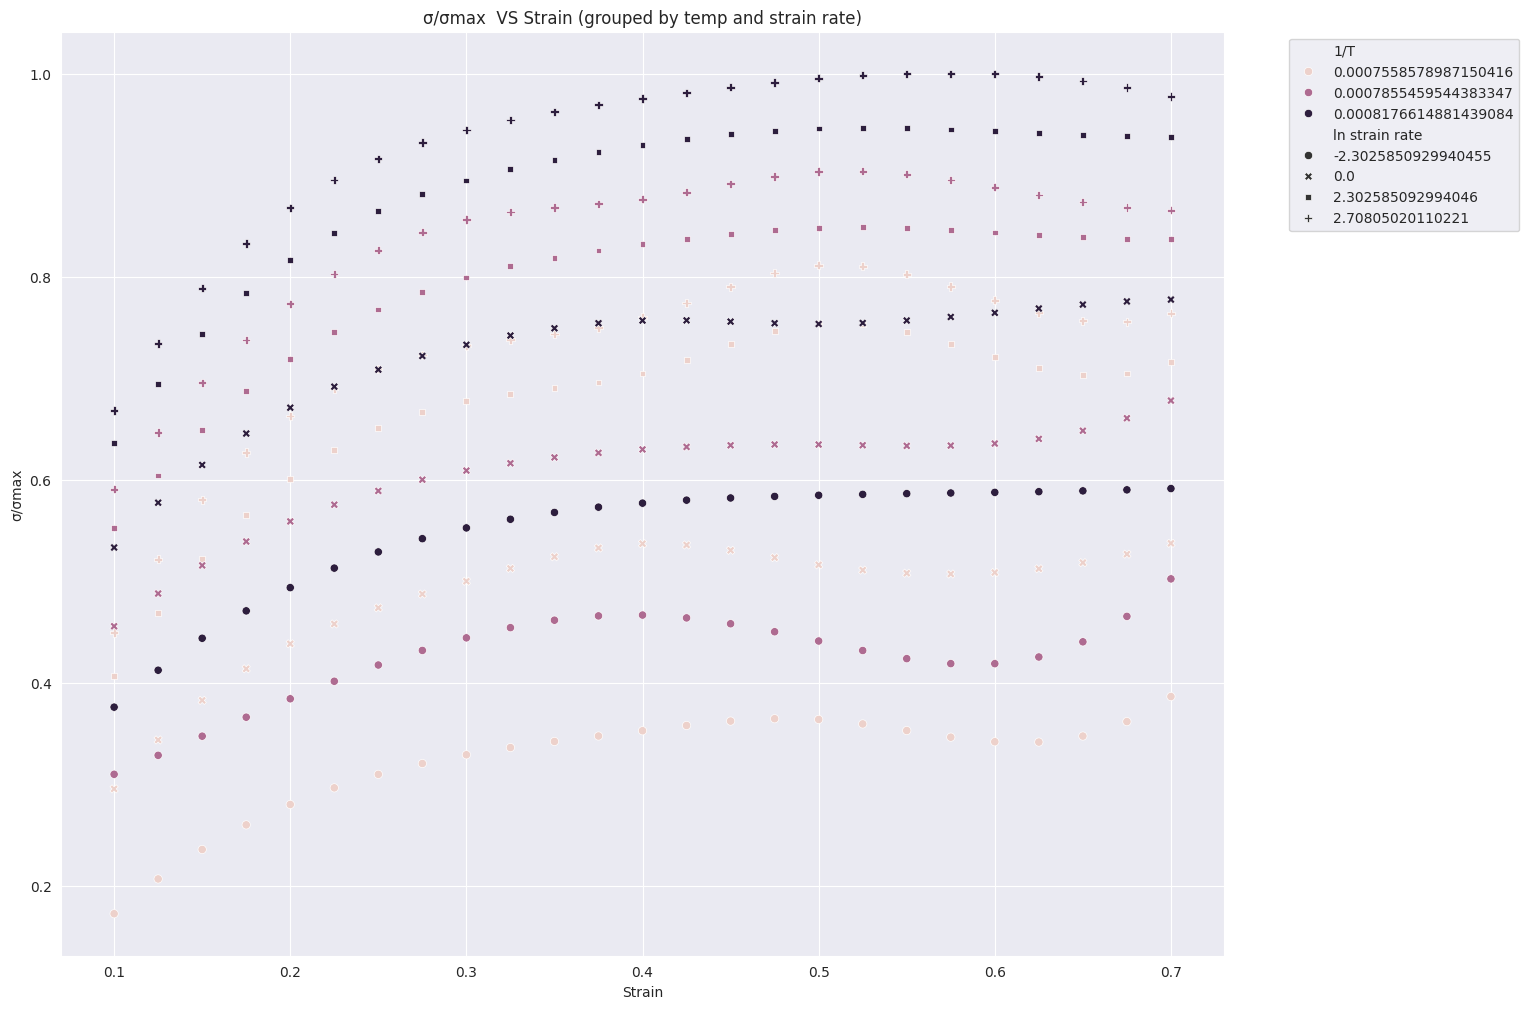

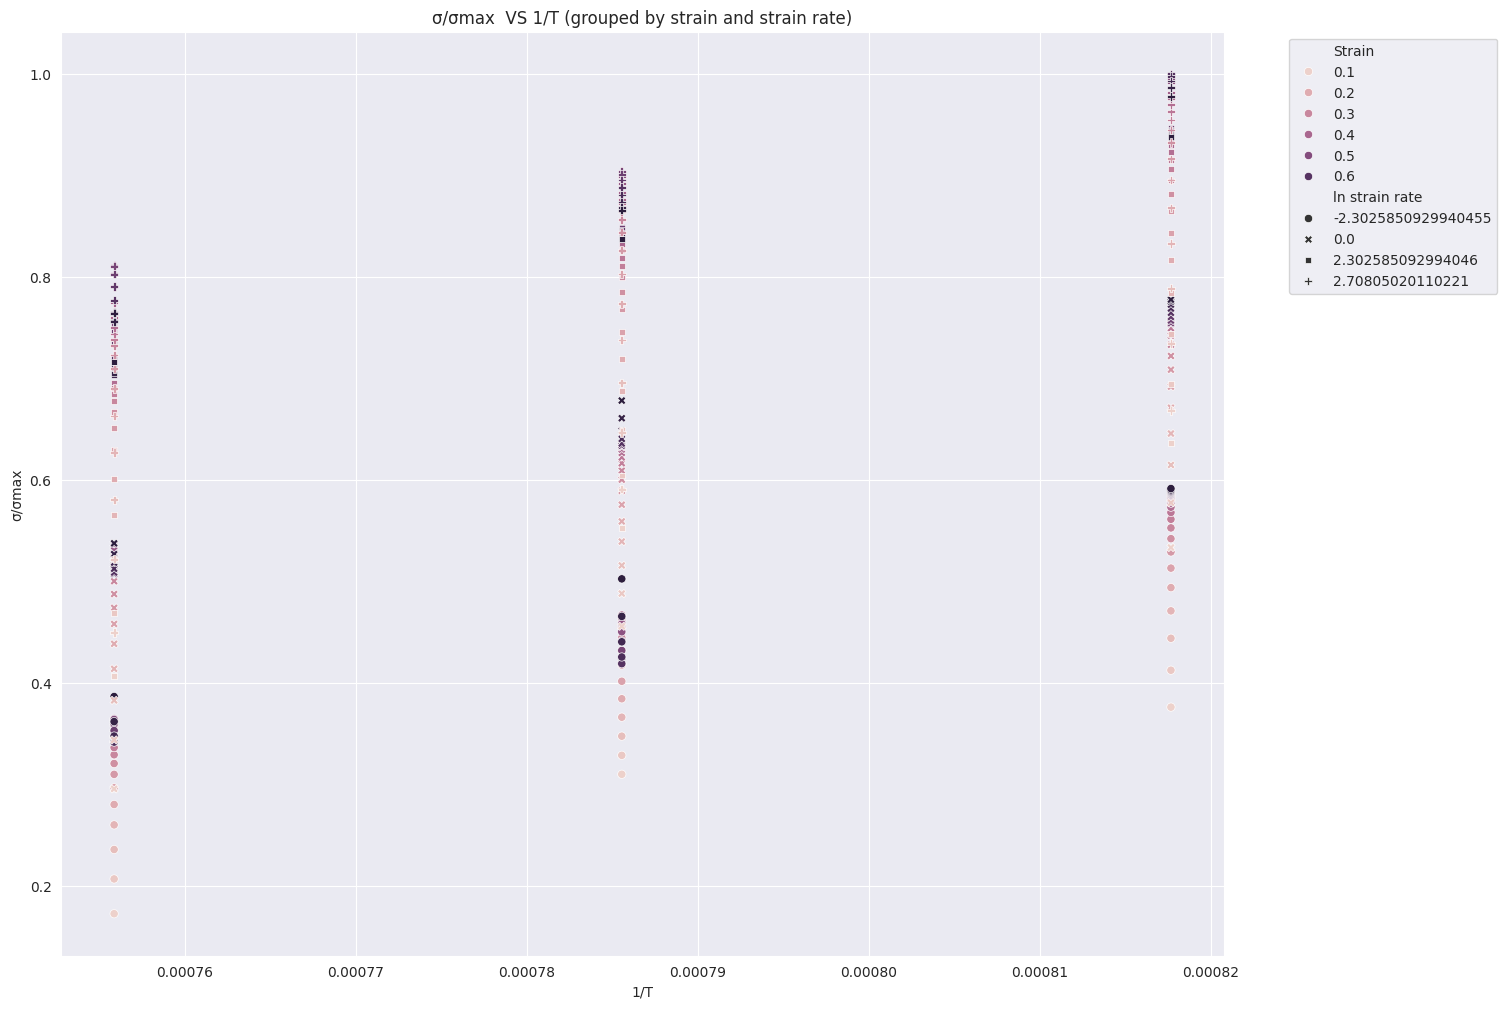

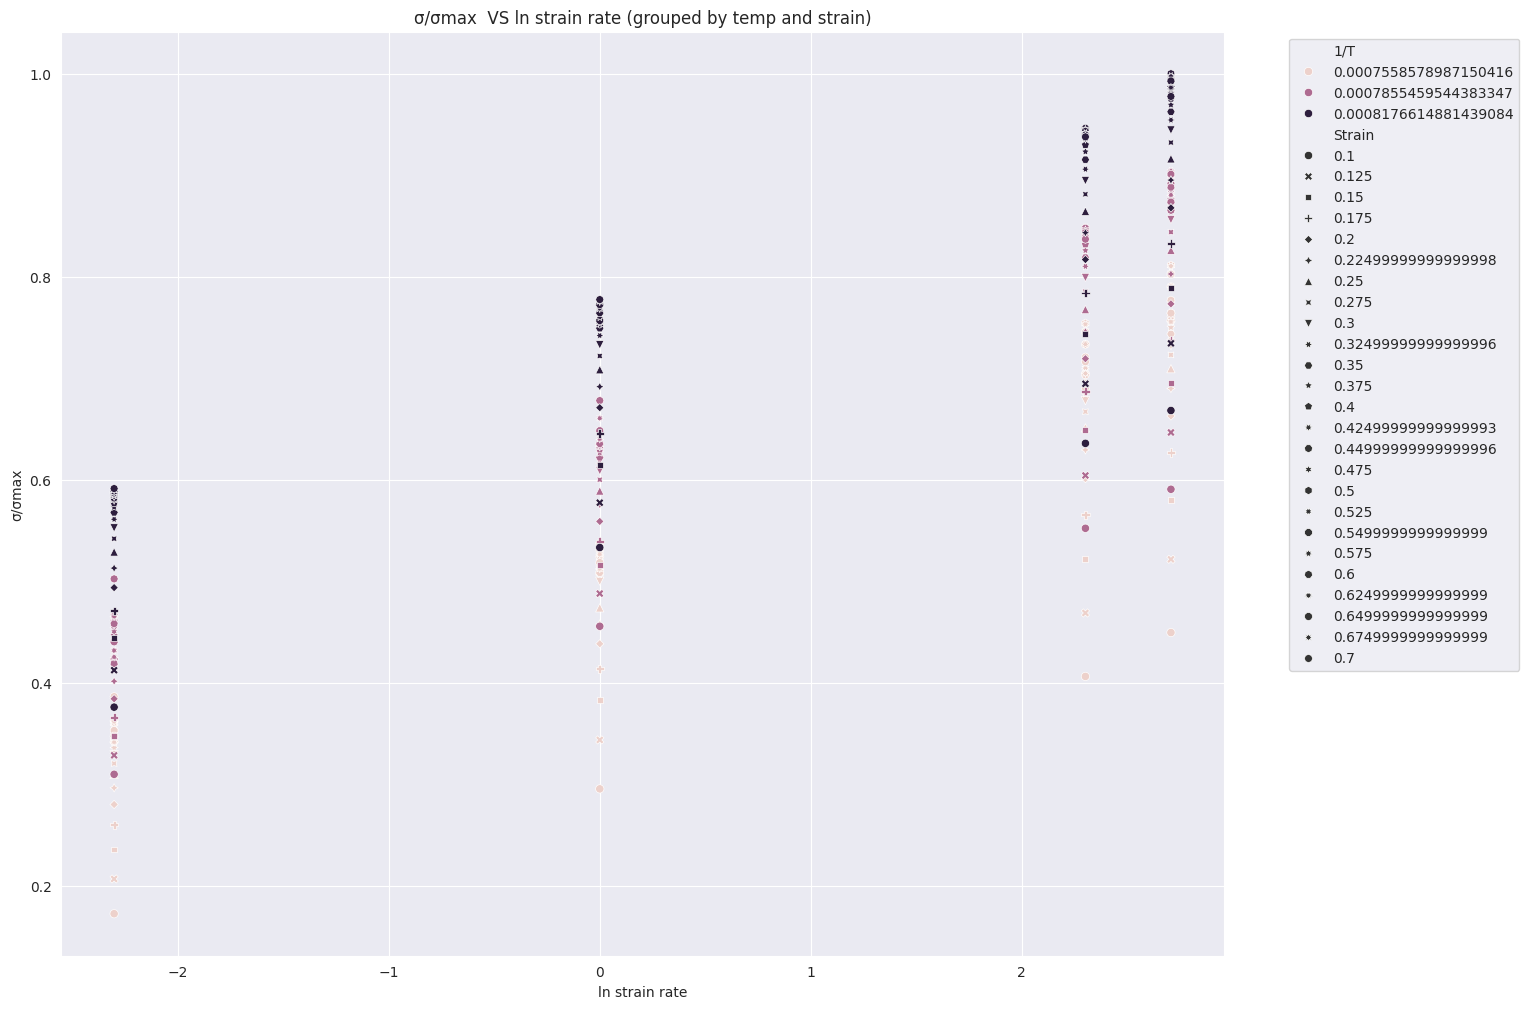

In [21]:
# Relationship plots - to understand the relationships between variables
# Step 1: σ/σmax  VS Strain ( grouped by temp and strain rate)
plt.figure(figsize=(15,12))
sns.scatterplot(data=df_interpolated, x='Strain', y = 'σ/σmax', hue = '1/T', style = 'ln strain rate')
plt.title('σ/σmax  VS Strain (grouped by temp and strain rate)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

# Step 2: σ/σmax vs 1/T (grouped by strain and strain rate)
plt.figure(figsize=(15,12))
sns.scatterplot(data = df_interpolated, x='1/T', y = 'σ/σmax', hue = 'Strain', style = 'ln strain rate')
plt.title('σ/σmax  VS 1/T (grouped by strain and strain rate)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()


# Step 3: σ/σmax vs ln strain rate (grouped by temp and strain)
plt.figure(figsize=(15,12))
sns.scatterplot(data = df_interpolated, x='ln strain rate', y = 'σ/σmax', hue = '1/T', style = 'Strain')
plt.title('σ/σmax  VS ln strain rate (grouped by temp and strain)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

## Interpolation Conclusions

Cubic spline interpolation was applied to expand the experimental dataset, with priority given to the two input dimensions that showed the largest gaps: **temperature (1/T)** and **strain rate (ln strain rate)**.

### Why Cubic Spline Interpolation

The exploratory plots showed smooth and well-behaved relationships across the input space. Cubic spline interpolation is appropriate in this case because it preserves smoothness by fitting a piecewise cubic polynomial through the known data points while maintaining continuity in both the function and its first derivative.

This makes it physically suitable for hot deformation data, where abrupt changes in flow stress are not expected between nearby experimental conditions.

### Interpolation Strategy

Interpolation was performed along the two most important sparse dimensions:

- **Along 1/T (temperature):** New intermediate temperature values were generated between the three experimental temperature levels. Temperature has a strong physical effect on flow stress, and the raw dataset contained only three measured levels, so interpolation along this axis provides meaningful improvement in resolution.

- **Along ln strain rate:** New intermediate strain rate values were generated, with particular focus on the large gap between **ln(ε̇) = 0** and **ln(ε̇) = 2.3**, where no experimental measurements existed. This was the most significant sparse region identified during EDA and is expected to benefit most from interpolation.

- **Strain:** Strain was retained at its original values (**0.1 to 0.7**) because it was already uniformly and sufficiently sampled in the raw dataset.

### Dataset Expansion

The interpolation process expanded the dataset from **84 experimental points** to **[X] total data points**. This provides the ANN with a denser and more continuous representation of the deformation surface while remaining anchored to the original experimental measurements.

### Validation

The interpolated values were checked to ensure that **σ/σmax** remained within the physically valid range of **[0, 1]** throughout the dataset.

The interpolated surface was also visually compared against the original data points to confirm that the generated values remained smooth, consistent, and physically realistic, with no obvious oscillations or unphysical artifacts.

### Output

The expanded dataset was saved as:

`data/processed/interpolated_data.xlsx`

This dataset is now ready for preprocessing and ANN model development.